# Lesson 115 · Graph ML design patterns: encoder → message passing → head

Student lab · Three live TODO/CHECK tasks. Default execution fits tiny synthetic examples; the named experiment is separately gated.

In [ ]:
# @colab-bootstrap · install missing packages only; print actual versions.
import importlib.util, importlib.metadata, subprocess, sys
required={'torch':'torch==2.8.0','numpy':'numpy==2.2.6','pandas':'pandas==2.3.2','ogb':'ogb==1.3.6','sklearn':'scikit-learn==1.7.1'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing: subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Python',sys.version)
print({k:importlib.metadata.version(k) for k in ['torch','numpy','pandas','ogb']})


## Runtime and source identity

Default execution needs no dataset download or repository imports. All implementation is visible below. The optional full run downloads an 80 MiB archive, verifies SHA-256 and runs all ten full schedules. Author runtime: Python 3.12, torch 2.8.0, NumPy 2.2.6, pandas 2.3.2, OGB 1.3.6, scikit-learn 1.7.1; independent original-source replay additionally uses PyG 2.6.1. Existing notebook package versions are printed, not silently represented as pinned. Live Colab NOT_CHECKED. [Protocol](https://avistian.github.io/relational/labs/l115-reproduction.md).

<p class="stream-kicker">Synthesis · one reusable design skill · three prediction units</p>

**Your win:** given a graph prediction problem, write a defensible encoder → processor → head design, name the prediction unit and information boundary, and show whether a refactor preserves the original computation.

The core reading takes about 25 minutes. Then spend 25–35 minutes on the three design rows and live notebook tasks. The ten-run author experiment is separate from that study session.

[Student notebook](https://avistian.github.io/relational/labs/0115-graph-ml-design-patterns.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0115-graph-ml-design-patterns.html) · [Quick reference](https://avistian.github.io/relational/reference/graph-ml-design-patterns.html) · [Reproduction ledger](https://avistian.github.io/relational/labs/l115-reproduction.md)

**Recall before reading:** What population enters the arxiv GCN forward pass? Which labels enter loss? What does validation select?



## 1 · Start with the prediction unit

[Lesson 114](https://avistian.github.io/relational/lessons/0114-ogb-error-analysis.html) asked where a trained GCN fails. Before choosing a replacement, we need a way to describe exactly what would change. An architecture name is insufficient: replacing a decoder, dropping an edge type, changing pooling, or exposing future events can each change the problem.

Write this sentence first: **“For each ___, predict ___ using information available at ___.”** A paper-topic classifier predicts a class per node. A citation model scores a directed candidate pair. A molecule classifier predicts once per graph. The three cases may share message passing, but their output rows, labels and losses mean different things. [OGB §3 and task definitions](https://arxiv.org/html/2005.00687v6#S3).

The organizing pattern is:

1. **Encoder:** turn available raw attributes into vectors with explicit type and missing-value semantics.
2. **Processor:** move and transform information along permitted graph connections.
3. **Head/readout:** select nodes, combine candidate endpoints, or pool within each graph, then produce scores with the required shape.
4. **Training contract:** define the supervised examples, loss, split, selection metric and saved state.

These are responsibilities, not a rule that every model must have exactly three learned layers. An encoder can be the identity. A head may itself aggregate neighbors. A decoder can be an MLP or another graph network. This lesson's decomposition is an engineering choice informed by the compositional view in [Battaglia et al., §4.3 and Figure 6b](https://arxiv.org/html/1806.01261v3#S4.SS3). It does not claim to reproduce that entire paper.

**Mission connection.** In [Lesson 076](https://avistian.github.io/relational/lessons/0076-encoder-predictor-stack.html), a database row became an embedding and joined a graph. Here we make the contract reusable: table encoders → typed relational propagation → target-row head. That becomes the explicit RDL stack in planned Lesson 131.



## 2 · Trace the complete GCN before naming its modules

We use the same named experiment as Lesson 112: the released three-layer GCN on ogbn-arxiv. There are N=169,343 papers, 128 input coordinates and 40 classes. The official split has 90,941 training, 29,799 validation and 48,603 test papers. The publication supplies the benchmark; the pinned release supplies the executable model and training defaults. [OGB §4.3/Table 6](https://arxiv.org/html/2005.00687v6#S4.SS3), [released GCN and training loop](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/gnn.py).

<figure class="stream-figure" tabindex="0">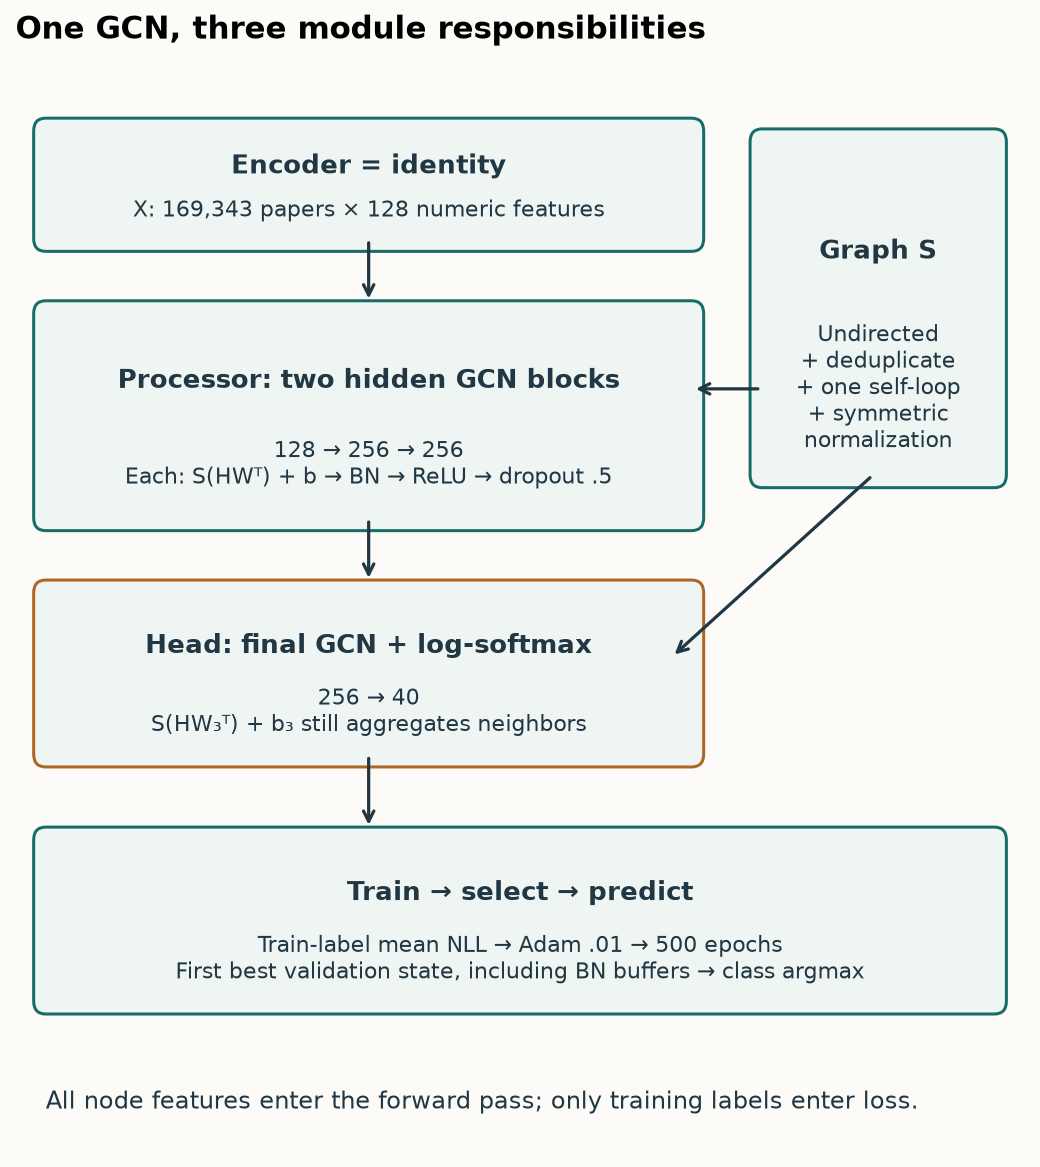<figcaption>The exact arxiv GCN: identity encoder, two hidden GCN blocks, a third graph convolution in the head, train-label loss and validation-selected inference.</figcaption></figure>

**Step A — make the graph operator explicit.** Deduplicate the citation graph after making it undirected, add one self-loop per node, then form S=D⁻¹ᐟ²(A+I)D⁻¹ᐟ². A matrix row identifies the receiving node; its nonzero columns identify senders. Degrees are measured after deduplication and loop addition. The operator stays fixed during this experiment.

**Step B — preserve the encoder.** Here E(X)=X. The input is already a numeric feature matrix. Adding a learned 128→256 projection merely to fill an “encoder” box would add parameters and change the experiment.

**Step C — process two hidden layers.** For each layer compute U=S(HWᵀ)+b, apply batch normalization, ReLU, then dropout with probability 0.5. Shapes are N×128 → N×256 → N×256. Batch normalization sees all nodes in the transductive training forward pass. Only the loss is restricted to training labels. Dropout is disabled at evaluation; saved BN statistics are restored with the selected weights.

**Step D — keep propagation inside the head.** The final layer computes N×40 class scores as S(HW₃ᵀ)+b₃, then log-softmax. An ordinary Linear(256,40) head would omit the third graph operation. Both return N×40, so shape checking alone cannot detect the mistake.

**Step E — train and select.** Mean negative log-likelihood uses training rows only. Adam uses learning rate 0.01 for 500 epochs. Each epoch is evaluated; the first maximum validation accuracy selects the state, including BN buffers. Test accuracy is reported from that selected state. Ten seeds measure variation under this fixed dataset and schedule. No test-driven tuning is performed.

```python
class GCN(nn.Module):
    # Full definitions are visible in the notebook and canonical source.
    def forward(self, x, adj):
        z = self.encoder(x)         # identity: [N, 128]
        h = self.processor(z, adj)  # two hidden GCN blocks: [N, 256]
        return self.head(h, adj)    # final GCN + log-softmax: [N, 40]
```

**Predict:** if the last layer has no activation before log-softmax, can we remove its graph multiplication?

<details><summary>Check the dependency, not just the activation</summary><p>No. Linearity does not make the graph operator the identity. The final class score still depends on neighboring hidden vectors. Removing S reduces propagation depth and changes the scores. Even bias placement matters: S(HWᵀ)+b is generally different from S(HWᵀ+b), because symmetric normalization need not have row sums of one.</p></details>

**Task 1:** implement `graph_forward`. Apply the encoder once, then processor once, then head once. Supply the same adjacency to both processor and head. The checker uses noncommuting operations; the reproduction additionally compares outputs, input and parameter gradients, BN buffers and an Adam update.



## 3 · Change the head when the question changes

Suppose the processor has produced node vectors Z. For the following arithmetic, take z₀=[1,2], z₁=[3,5], z₂=[7,11]. These are fixed synthetic vectors, not learned explanations of the arxiv model.

<figure class="stream-figure" tabindex="0">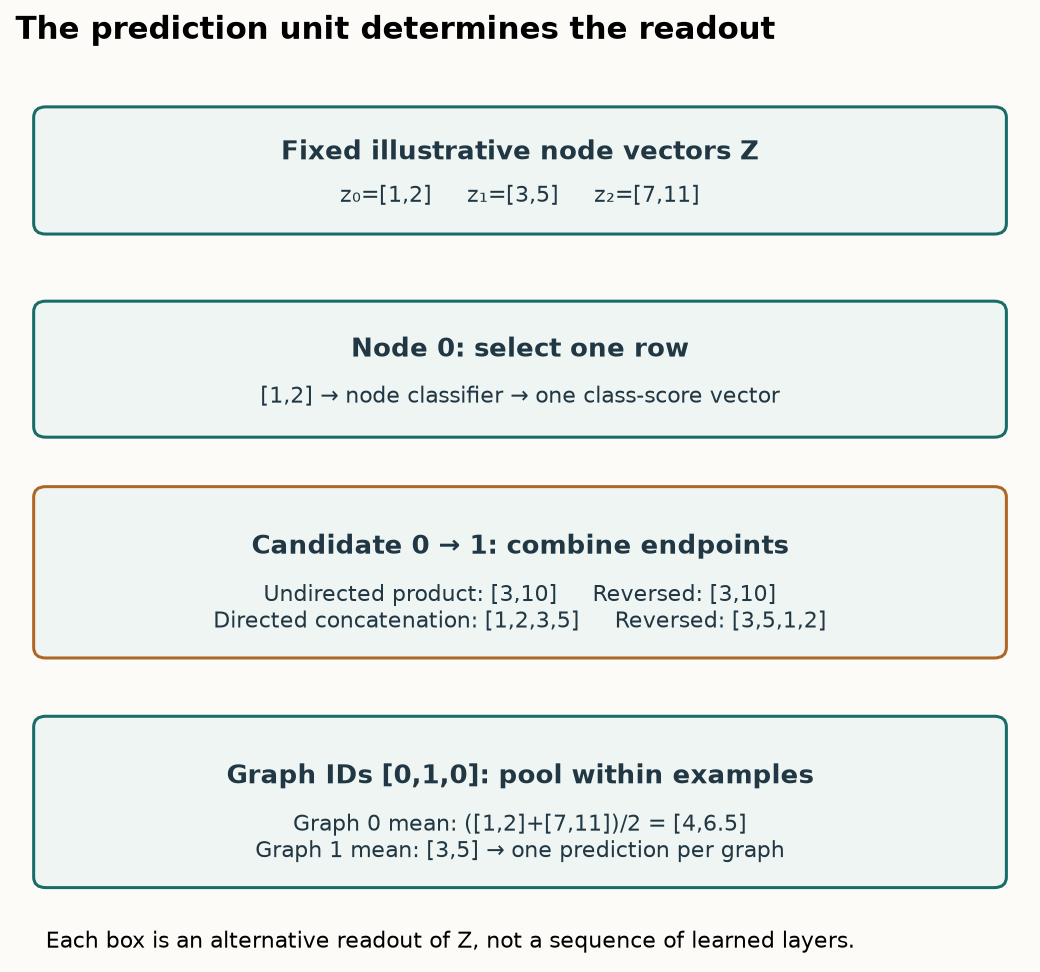<figcaption>Fixed synthetic vectors illustrate node selection, endpoint composition and within-graph pooling. These are alternative heads, not sequential layers.</figcaption></figure>

**Node prediction.** Select the target node's vector and map its d coordinates to C class scores. For ordinary nodewise Linear heads, output shape is N×C; a seed-node mini-batch loss uses only seed outputs. Our reproduction uses a propagating node head, so its contract additionally requires adjacency. Selection does not mean deleting context nodes before message passing.

**Undirected link prediction.** Construct a vector from each candidate pair. Elementwise product gives z₀⊙z₁=[3,10], unchanged when endpoints swap. A learned linear score on that product is therefore symmetric. This is a valid deliberate constraint for an undirected relation; it is not a universal link decoder.

**Directed link prediction.** Ordered concatenation gives [z₀,z₁]=[1,2,3,5]; reversing endpoints yields [3,5,1,2]. A learned decoder can distinguish those orders. Concatenation permits asymmetry but does not guarantee it: symmetric learned weights could still yield equal scores. Heterogeneous links additionally need endpoint-type and relation semantics. A same-width tensor does not establish compatible meaning.

**Graph prediction.** For batch IDs [0,1,0], graph 0 contains nodes 0 and 2, so its mean is [4,6.5]; graph 1 contains node 1, so its mean is [3,5]. Pooling all three rows produces one vector [11/3,6] and loses the distinction between examples. Apply the graph head after per-graph pooling to produce B×C scores, where B is the number of graphs. [Gilmer et al., §2: message passing and readout](https://proceedings.mlr.press/v70/gilmer17a.html).

Mean and sum answer different questions. Duplicating every vector in a graph leaves its mean unchanged but doubles its sum. If graph size is predictive, mean alone can discard useful information; sum or an explicit size feature is an alternative to test. This is a modeling decision, not a universally superior pooling rule.

Baseline: node 0 selects [1,2]; pair 0→1 gives product [3,10] or ordered concatenation [1,2,3,5]; graph IDs [0,1,0] give means [[4,6.5],[3,5]]. Reverse the pair and recompute before checking the notebook.

**Task 2:** implement `pair_features(z,pairs,directed)`. Use elementwise product for undirected candidates and ordered concatenation for directed candidates. Explain the invariance being imposed, not just the resulting width.

**Task 3:** implement `graph_mean(z,batch,num_graphs)`. Accumulate per-graph sums and counts; divide within each graph. Our explicit empty-graph convention is a zero vector. A real benchmark may exclude empty graphs or require a different convention; record it instead of letting division by zero choose for you.

<details><summary>What must a link training protocol add?</summary><p>Candidate pairs and labels, an allowed message graph, a negative-sampling rule, an objective, and a ranking/evaluation population. Avoid letting held-out positive target edges enter the training message graph. A binary loss on arbitrary negatives is not automatically equivalent to a benchmark's ranking protocol. The small link exercise below supplies its pairs explicitly and makes no link-benchmark claim.</p></details>



## 4 · Protect the information boundary across modules

<figure class="stream-figure" tabindex="0">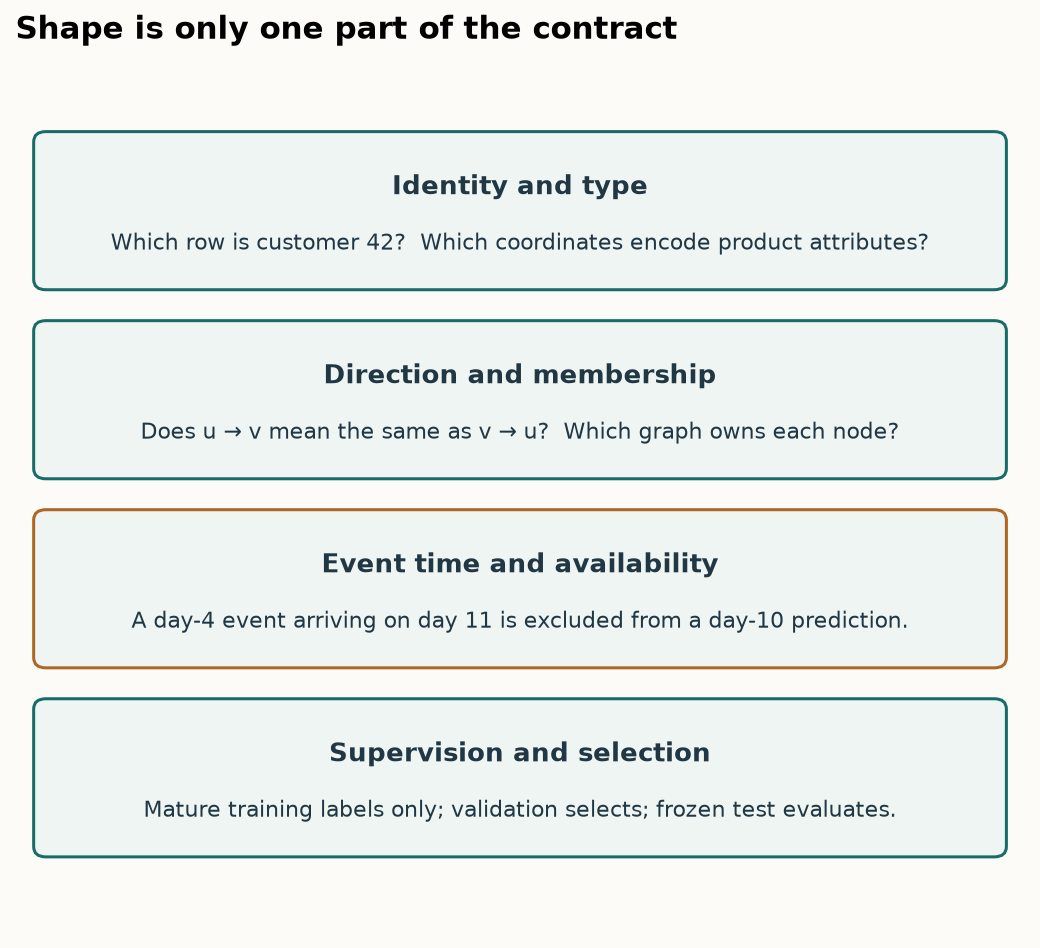<figcaption>Every module preserves row identity, type, edge direction, graph membership, visibility and supervision boundaries.</figcaption></figure>

A module interface needs more than a shape. Write down **row identity, type, graph membership, edge direction, and time visibility** wherever they matter.

| Situation | Encoder responsibility | Processor responsibility | Head and supervision responsibility |
|---|---|---|---|
| Static homogeneous nodes | Use the specified feature representation | Respect declared graph visibility and normalization | Preserve target IDs; mask loss to authorized labels |
| Heterogeneous entities | Encode each type with its feature schema | Route each typed relation in its defined direction | Select the target type; decode endpoints with their relation semantics |
| Independent graphs | Encode attributes consistently across examples | Keep adjacency block-diagonal across graph IDs | Pool within each graph; one label per graph |
| Temporal events or rows | Use attribute versions available at the cutoff | Apply event and availability cutoffs at every hop | Predict before updating with the target event; train only on mature labels |

The temporal row is a point-in-time contract from [Lesson 109](https://avistian.github.io/relational/lessons/0109-database-timestamp-contracts.html), not the arxiv reproduction protocol. A dataset split by publication year does not by itself turn a transductive full-graph GCN into a historical snapshot system. For this OGB baseline, later nodes' features and graph structure are visible according to the released transductive setup, while held-out labels never enter the loss.

The reusable [Lesson 076 cutoff/reduction widget](https://avistian.github.io/relational/lessons/0076-encoder-predictor-stack.html) makes the availability boundary concrete. Moving the cutoff changes which rows reach the processor; changing mean to sum changes the meaning of their aggregation.

At cutoff day 10, an event occurring on day 4 but available on day 11 must be excluded. Raising the cutoff to day 11 admits it, provided the event precedes the query under your declared time convention.

**A debugging order:** check IDs and visibility → check shapes and invariances → check forward values and gradients → check optimization and selection → compare the final metric. A close metric alone can hide offsetting errors. Lesson 116 will turn this order into a symptom-driven debugging practice.



## 5 · Refactoring is an empirical claim

Our claim is narrow: the modular GCN retains the released model's computation, under matched inputs, weights, buffers and random masks. Tests cover training and evaluation, including dropout. The flat-versus-modular comparison checks an Adam update in training mode. The independent PyG source comparison checks forward and gradients in both modes; its optimizer comparison uses evaluation-mode BN to avoid amplifying tiny near-zero pre-BN bias-gradient differences. That check does not establish identical historical training trajectories.

Fresh full-data training then checks the selected named experiment. The two checks answer different questions: operator parity asks whether the implementations agree under controlled conditions; benchmark reproduction asks what the complete declared protocol produces.

**Author-reference evidence: fresh training, separate from your kernel execution.**

| Population | Mean accuracy | Sample seed SD | Paper mean | Verdict |
|---|---:|---:|---:|---|
| valid | 73.1471% | 0.0878 pp | 73.00% | CLOSE |
| test | 71.9713% | 0.2476 pp | 71.74% | CLOSE |

The descriptive tolerance was declared before training: absolute mean difference ≤0.5 percentage points. Variance is reported, not required to match. Ten-run seed SD measures training variation on this graph; it is not uncertainty over independent datasets. All **1,693,430 final node predictions** were independently scored and replayed through the original model, with zero class mismatches.

The recorded pilot-plus-ten-fit worker-resource estimate is **USD0.2073**, excluding unitemized startup/build/storage overhead. The conservative worker ceiling is USD1.497312, with USD8.502688 reserved under the USD10 aggregate plan. [Full evidence](https://avistian.github.io/relational/labs/evidence/l115/summary.json).

<figure class="stream-figure" tabindex="0">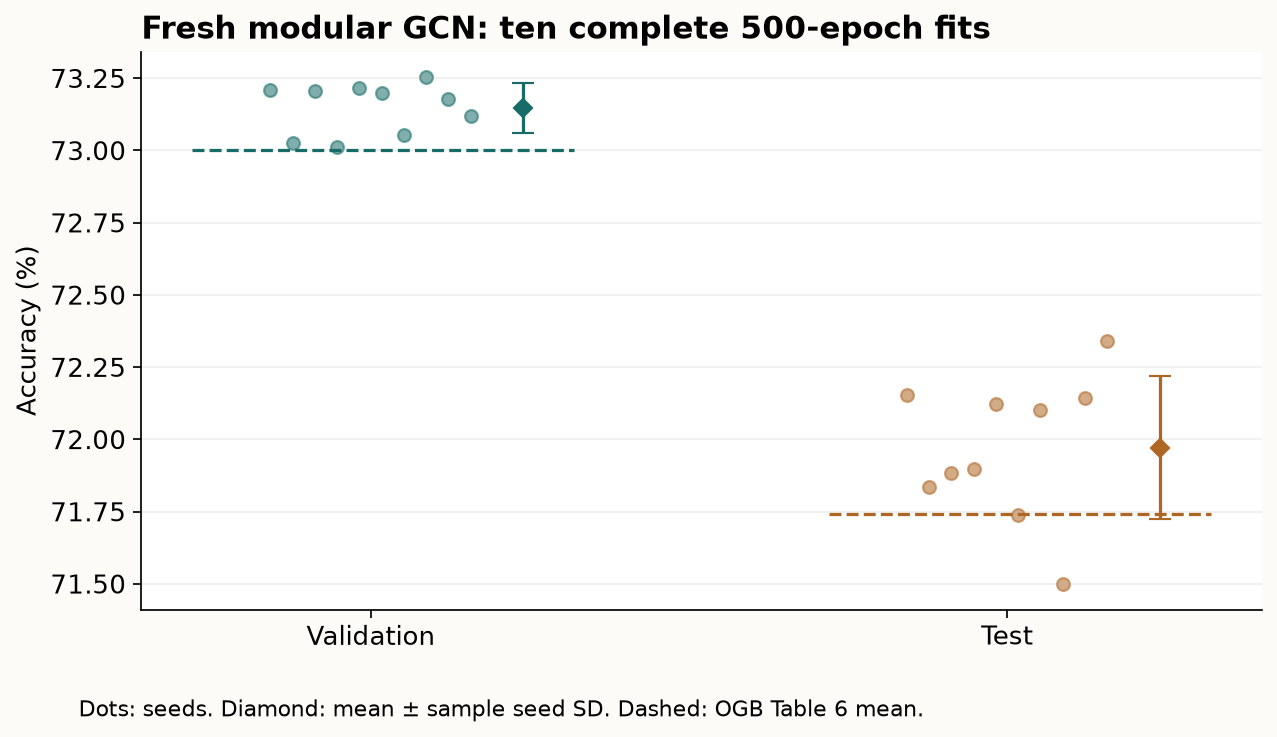<figcaption>Ten fresh full-data modular GCN fits, 500 epochs each. Dots are seeds; diamonds and whiskers are mean and sample seed SD; dashed lines are published means.</figcaption></figure>

Read [the protocol and deviation ledger](https://avistian.github.io/relational/labs/l115-reproduction.md) before calling this “full reproduction.” The completed scope is ten fresh fits for **one published GCN experiment**, with independent scoring and original-code checkpoint replay. Historical randomness, historical software identity and the rest of the OGB paper are not established. The link/graph runs in the notebook are synthetic course examples, not extra paper benchmarks.

The student notebook includes all load-bearing code: graph construction, modular model, loss, selection, trainer, pair composition and graph pooling. Its default run executes the three live tasks on small examples; a separate full-reproduction switch uses the full dataset and ten-seed schedule. The author results do not imply that your notebook trained those models.



## 6 · Your design table and written defense

Fill all columns **before** opening the solution. The three task specs are deliberately different:

| Task spec | Encoder | Processor + visibility | Head + output shape | Loss and selection | One invariant / failure probe |
|---|---|---|---|---|---|
| A: classify each paper into 40 topics under the released arxiv protocol | Your choice | Your choice | Your choice | Your choice | Your choice |
| B: score whether customer u buys product v in the next 7 days using records available at cutoff t | Your choice | Your choice | Your choice | Your choice | Your choice |
| C: classify each independent molecular graph, using atom and bond attributes | Your choice | Your choice | Your choice | Your choice | Your choice |

<details><summary>Design feedback — open after writing</summary><p>A: identity numeric encoder; complete released undirected normalized graph; two hidden GCN blocks and a third propagating class head; N×40 log probabilities; train-label NLL and first best validation accuracy; compare outputs/gradients and preserve BN population. B: customer/product-specific encoders; directed typed historical interactions with event and availability times no later than t at every hop; ordered pair or relation-aware decoder, one score per candidate pair; binary loss with an explicit negative population or an explicitly defined ranking objective; validate on future windows with mature labels and matching candidate populations. Probe reversed endpoints and a late-arriving event. C: atom encoder with bond-aware messages; disconnected graphs retain batch IDs; invariant per-graph readout then graph classifier; one label per graph, split/metric chosen for the actual benchmark. Probe node permutation and cross-graph contamination. B and C are defensible starting designs, not uniquely correct architectures or executed benchmark protocols.</p></details>

**EXIT:** submit the three functions, your table, and a short defense explaining (1) why the GCN head needs adjacency, (2) what information each task may use, (3) why product and concatenation impose different link symmetries, (4) why pooling needs graph IDs, and (5) what the reproduced experiment does and does not establish. Passing automated checks alone leaves **PENDING_WRITTEN_DEFENSE**.

**Teach back:** Explain why a shape-preserving refactor can still alter propagation, normalization, visibility or the unit of prediction.

**Spacing:** tomorrow, redraw the complete GCN without looking and mark all three graph multiplications. In a week, design task B again with a late-arriving purchase and explain exactly where it must be excluded. Interleave a node task and a graph task to practice identifying the unit of supervision.

**Primary reading:** Battaglia et al., [Relational inductive biases, deep learning, and graph networks, §4.3](https://arxiv.org/html/1806.01261v3#S4.SS3). Pair the conceptual composition with the [pinned OGB implementation](https://github.com/snap-stanford/ogb/blob/61e9784ca76edeaa6e259ba0f836099608ff0586/examples/nodeproppred/arxiv/gnn.py). Ask your tutor follow-up questions wherever a tensor boundary, source claim or experimental conclusion is unclear.


## Visible implementation

Adapted from the pinned MIT-licensed OGB GCN, with explicit modular boundaries. See [source and license](https://github.com/snap-stanford/ogb/tree/61e9784ca76edeaa6e259ba0f836099608ff0586). The same three functions you implement below are used by the RUN examples.

### Imports and frozen experiment · PROVIDED

In [ ]:
"""L115: source-preserving modular GCN and task readouts.
Architecture follows OGB's MIT-licensed gnn.py; see labs/sources/l115/LICENSE.
"""
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from ogb.nodeproppred import Evaluator

DATA_URL='https://snap.stanford.edu/ogb/data/nodeproppred/arxiv.zip'
DATA_SHA256='49f85c801589ecdcc52cfaca99693aaea7b8af16a9ac3f41dd85a5f3193fe276'
TARGETS={'valid':73.00,'test':71.74}
TOLERANCE_PP=0.5

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''):h.update(chunk)
    return h.hexdigest()

### Normalized message passing · PROVIDED

In [ ]:
def normalized_adjacency(edge_index, num_nodes):
    """Binary undirected graph + one self loop, then D^-1/2 A D^-1/2.

    Matrix rows are receivers and columns are senders. Deduplicate BEFORE
    measuring degrees: reciprocal citations must not get extra weight.
    """
    e=edge_index.cpu().long()
    loops=torch.arange(num_nodes).repeat(2,1)
    idx=torch.cat([e,e.flip(0),loops],dim=1)
    a=torch.sparse_coo_tensor(idx,torch.ones(idx.shape[1]),(num_nodes,num_nodes)).coalesce()
    row,col=a.indices()
    degree=torch.bincount(row,minlength=num_nodes).float()
    inv=degree.rsqrt()
    values=inv[row]*inv[col]
    return torch.sparse_coo_tensor(a.indices(),values,a.shape).coalesce().to_sparse_csr()

### Complete GCN architecture · PROVIDED

In [ ]:
class GraphConvolution(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.weight=nn.Parameter(torch.empty(out_channels,in_channels))
        self.bias=nn.Parameter(torch.empty(out_channels))
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    def forward(self,x,adj):
        return torch.sparse.mm(adj,F.linear(x,self.weight))+self.bias

### Task 1: compose the model without changing its operators

**Goal:** Compose the three live modules once each; preserve adjacency at both graph operations.

In [ ]:
def graph_forward(encoder,processor,head,x,adj):
    raise NotImplementedError("TODO: graph_forward")

In [ ]:
def check_compose(fn):
    calls=[]
    def encode(x):calls.append('encoder');return x+2
    def process(x,a):calls.append('processor');return a@x
    def head(x,a):calls.append('head');return a@x-1
    x=torch.tensor([[1.],[3.]]);a=torch.tensor([[0.,1.],[1.,0.]])
    torch.testing.assert_close(fn(encode,process,head,x,a),torch.tensor([[2.],[4.]]))
    assert calls==['encoder','processor','head']
check_compose(graph_forward)
print("PASS: graph_forward")

### Modular GCN: identity encoder, hidden processor, propagating head · PROVIDED

In [ ]:
class GCNProcessor(nn.Module):
    def __init__(self,in_channels,hidden_channels,dropout):
        super().__init__()
        self.convs=nn.ModuleList([GraphConvolution(in_channels,hidden_channels),GraphConvolution(hidden_channels,hidden_channels)])
        self.bns=nn.ModuleList([nn.BatchNorm1d(hidden_channels),nn.BatchNorm1d(hidden_channels)])
        self.dropout=dropout
    def forward(self,x,adj):
        for conv,bn in zip(self.convs,self.bns):
            x=F.dropout(F.relu(bn(conv(x,adj))),p=self.dropout,training=self.training)
        return x

class PropagatingNodeHead(nn.Module):
    def __init__(self,hidden_channels,out_channels):
        super().__init__();self.conv=GraphConvolution(hidden_channels,out_channels)
    def forward(self,x,adj):
        return self.conv(x,adj).log_softmax(dim=-1)

class GCN(nn.Module):
    """Exact released operations: identity -> two hidden blocks -> final GCN."""
    def __init__(self,in_channels=128,hidden_channels=256,out_channels=40,dropout=.5):
        super().__init__()
        self.encoder=nn.Identity()
        self.processor=GCNProcessor(in_channels,hidden_channels,dropout)
        self.head=PropagatingNodeHead(hidden_channels,out_channels)
    def reset_parameters(self):
        # Preserve the release reset order: ALL convolutions, then BN buffers.
        for conv in [*self.processor.convs,self.head.conv]:conv.reset_parameters()
        for bn in self.processor.bns:bn.reset_parameters()
    def forward(self,x,adj):
        return graph_forward(self.encoder,self.processor,self.head,x,adj)

def release_state(model):
    """Explicit parameter/buffer names for the flat reference, not a second model."""
    return {k.replace('processor.','').replace('head.conv.','convs.2.'):v for k,v in model.state_dict().items()}

### Task 2: preserve or remove link direction deliberately

**Goal:** Use symmetric product or ordered concatenation according to the link direction contract.

In [ ]:
def pair_features(z,pairs,directed=False):
    raise NotImplementedError("TODO: pair_features")

In [ ]:
def check_pairs(fn):
    x=torch.tensor([[1.,2.],[3.,5.],[7.,11.]],requires_grad=True)
    pairs=torch.tensor([[0,1,2],[1,0,2]])
    a=fn(x,pairs,False);b=fn(x,pairs,True)
    torch.testing.assert_close(a,torch.tensor([[3.,10.],[3.,10.],[49.,121.]]))
    torch.testing.assert_close(b,torch.tensor([[1.,2.,3.,5.],[3.,5.,1.,2.],[7.,11.,7.,11.]]))
    assert not torch.equal(b[0],b[1])
    b.sum().backward();torch.testing.assert_close(x.grad,torch.full_like(x,2.))
check_pairs(pair_features)
print("PASS: pair_features")

### Task 3: pool within graph boundaries

**Goal:** Group by graph IDs, compute means and return zero for explicitly empty graphs.

In [ ]:
def graph_mean(z,batch,num_graphs):
    raise NotImplementedError("TODO: graph_mean")

In [ ]:
def check_pool(fn):
    x=torch.tensor([[1.,3.],[7.,9.],[3.,5.]],requires_grad=True);batch=torch.tensor([0,1,0])
    out=fn(x,batch,3)
    torch.testing.assert_close(out,torch.tensor([[2.,4.],[7.,9.],[0.,0.]]))
    perm=torch.tensor([2,0,1]);torch.testing.assert_close(fn(x[perm],batch[perm],3),out)
    out.sum().backward();torch.testing.assert_close(x.grad,torch.tensor([[.5,.5],[1.,1.],[.5,.5]]))
    torch.testing.assert_close(fn(x.detach().repeat_interleave(2,0),batch.repeat_interleave(2),3),out)
check_pool(graph_mean)
print("PASS: graph_mean")

### Train on authorized labels · PROVIDED

In [ ]:
def training_loss(log_probs, labels, train_idx):
    return F.nll_loss(log_probs[train_idx],labels[train_idx])

### Validation chooses the checkpoint · PROVIDED

In [ ]:
def selected_epoch(validation_scores):
    """Zero-based index, first maximizer, matching released torch.argmax."""
    if not len(validation_scores):raise ValueError('No evaluated epochs')
    return int(np.argmax(validation_scores))

### Raw release, official split files, data integrity · PROVIDED

In [ ]:
def load_arxiv(root):
    root=Path(root);root.mkdir(parents=True,exist_ok=True);archive=root/'arxiv.zip'
    if not archive.exists():
        temp=archive.with_suffix('.partial');urllib.request.urlretrieve(DATA_URL,temp);temp.replace(archive)
    actual=sha256(archive)
    if actual!=DATA_SHA256:raise ValueError(f'Dataset hash mismatch: {actual}')
    with zipfile.ZipFile(archive) as z:
        def read(name,dtype):
            with z.open('arxiv/'+name) as f:return pd.read_csv(f,header=None,compression='gzip').to_numpy(dtype=dtype)
        x=read('raw/node-feat.csv.gz',np.float32)
        edge=read('raw/edge.csv.gz',np.int64).T.copy()
        y=read('raw/node-label.csv.gz',np.int64).reshape(-1)
        year=read('raw/node_year.csv.gz',np.int64).reshape(-1)
        split={k:read(f'split/time/{k}.csv.gz',np.int64).reshape(-1) for k in ['train','valid','test']}
    assert x.shape==(169343,128) and edge.shape==(2,1166243)
    assert y.min()==0 and y.max()==39
    joined=np.concatenate(list(split.values()));assert np.array_equal(np.sort(joined),np.arange(len(y)))
    assert np.all(year[split['train']]<=2017)
    assert np.all(year[split['valid']]==2018)
    assert np.all(year[split['test']]>=2019)
    audit={'archive_sha256':actual,'nodes':len(y),'directed_edges':edge.shape[1],'features':x.shape[1],'classes':40,'splits':{k:len(v) for k,v in split.items()},'year_ranges':{k:[int(year[v].min()),int(year[v].max())] for k,v in split.items()},'arrays_sha256':{k:hashlib.sha256(v.tobytes()).hexdigest() for k,v in {'x':x,'edge':edge,'y':y,'year':year,**split}.items()}}
    return torch.from_numpy(x),torch.from_numpy(edge),torch.from_numpy(y),{k:torch.from_numpy(v) for k,v in split.items()},audit

### Full training and selected-state replay · PROVIDED

In [ ]:
@torch.no_grad()
def evaluate(model,x,adj,y,split):
    model.eval();pred=model(x,adj).argmax(1).cpu().numpy().reshape(-1,1)
    evaluator=Evaluator(name='ogbn-arxiv');labels=y.cpu().numpy().reshape(-1,1)
    scores={k:float(evaluator.eval({'y_true':labels[v.cpu().numpy()],'y_pred':pred[v.cpu().numpy()]})['acc']) for k,v in split.items()}
    return scores,pred.reshape(-1)

def train_run(x,adj,y,split,seed,epochs,output,device='cpu'):
    output=Path(output)
    if (output/'result.json').exists():raise FileExistsError('Use a fresh output directory; no silent resume')
    output.mkdir(parents=True,exist_ok=True)
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)
    model=GCN().to(device);model.reset_parameters()
    x=x.to(device);adj=adj.to(device);y=y.to(device);split={k:v.to(device) for k,v in split.items()}
    optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    history=[];best=-1.;state=None;start=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad();loss=training_loss(model(x,adj),y,split['train']);loss.backward();optimizer.step()
        scores,_=evaluate(model,x,adj,y,split)
        history.append({'epoch':epoch+1,'loss':float(loss.detach()),**scores})
        # Strict improvement saves the first maximum, including BN buffers.
        if scores['valid']>best:
            best=scores['valid'];state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if (epoch+1)%50==0:print(json.dumps({'seed':seed,**history[-1],'elapsed':time.perf_counter()-start}),flush=True)
    chosen=selected_epoch([r['valid'] for r in history]);model.load_state_dict(state)
    scores,pred=evaluate(model,x,adj,y,split)
    assert scores=={k:history[chosen][k] for k in split}
    torch.save(state,output/'checkpoint.pt')
    np.savez_compressed(output/'predictions.npz',pred=pred,y=y.cpu().numpy(),**{k:v.cpu().numpy() for k,v in split.items()})
    result={'seed':seed,'epochs':epochs,'selected_epoch':chosen+1,'scores':scores,'seconds':time.perf_counter()-start,'parameters':sum(p.numel() for p in model.parameters()),'history':history,'checkpoint_sha256':sha256(output/'checkpoint.pt'),'predictions_sha256':sha256(output/'predictions.npz'),'device':device,'torch':torch.__version__,'numpy':np.__version__,'status':'COMPLETE' if epochs==500 else 'TEACHING_ONLY'}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## RUN · exercise your live modules

Node example trains the tiny modular GCN. Link and graph examples train readout heads on fixed synthetic embeddings. All fit and score the same examples: these verify executable composition, not generalization or benchmark parity.

In [ ]:
# RUN: your live graph_forward, pair_features and graph_mean are all used here.
torch.set_num_threads(1);torch.manual_seed(31)
# Node task: two disconnected groups, fixed synthetic attributes and labels.
x=torch.tensor([[1.,0.],[1.1,.1],[.9,-.1],[-1.,0.],[-1.1,.1],[-.9,-.1]])
edges=torch.tensor([[0,1,2,3,4,5],[1,2,0,4,5,3]])
adj=normalized_adjacency(edges,6);y=torch.tensor([0,0,0,1,1,1])
model=GCN(2,8,2,dropout=0.);opt=torch.optim.Adam(model.parameters(),lr=.03)
losses=[]
for step in range(60):
    model.train();opt.zero_grad();loss=F.nll_loss(model(x,adj),y);loss.backward();opt.step();losses.append(float(loss.detach()))
model.eval();node_pred=model(x,adj).argmax(1)
assert losses[-1]<losses[0] and torch.equal(node_pred,y)
# Link readout task: fixed Z and explicit directed candidate labels.
# These pairs are supervised examples, not edges fed into a message graph.
z=torch.tensor([[1.,2.],[3.,5.],[7.,11.]])
pairs=torch.tensor([[0,1,0,2,1,2],[1,0,2,0,2,1]])
link_y=torch.tensor([1.,0.,1.,0.,1.,0.]) # later-index destination, illustrative rule
features=pair_features(z,pairs,True);link_head=nn.Linear(4,1)
opt=torch.optim.Adam(link_head.parameters(),lr=.08);link_losses=[]
for step in range(120):
    opt.zero_grad();score=link_head(features).flatten();loss=F.binary_cross_entropy_with_logits(score,link_y);loss.backward();opt.step();link_losses.append(float(loss.detach()))
assert link_losses[-1]<link_losses[0]
assert torch.equal((link_head(features).flatten()>0).long(),link_y.long())
# Graph readout task: batch IDs preserve two differently sized examples.
batch=torch.tensor([0,1,0]);pooled=graph_mean(z,batch,2)
graph_y=torch.tensor([1,0]);graph_head=nn.Linear(2,2);opt=torch.optim.Adam(graph_head.parameters(),lr=.08);graph_losses=[]
for step in range(160):
    opt.zero_grad();loss=F.cross_entropy(graph_head(pooled),graph_y);loss.backward();opt.step();graph_losses.append(float(loss.detach()))
assert graph_losses[-1]<graph_losses[0] and torch.equal(graph_head(pooled).argmax(1),graph_y)
report={'status':'PASS','scope':'SYNTHETIC_COURSE_EXAMPLES; fit and score same tiny examples, no held-out generalization claim','node':{'shape':list(model(x,adj).shape),'loss_first':losses[0],'loss_last':losses[-1]},'link':{'shape':list(features.shape),'loss_first':link_losses[0],'loss_last':link_losses[-1],'labels':'Explicit illustrative candidate labels; not a benchmark negative sampler'},'graph':{'pooled':pooled.tolist(),'loss_first':graph_losses[0],'loss_last':graph_losses[-1]},'learner_status':'PENDING_WRITTEN_DEFENSE'}
Path('l115-task-report.json').write_text(json.dumps(report,indent=2));print(json.dumps(report,indent=2))


## Full named reproduction gate

The default does not launch full training. The complete author experiment uses bounded Modal workers described in the protocol, with a USD10 aggregate plan. The notebook switch itself does not enforce a cloud spending limit.

In [ ]:
# Full named experiment: complete raw data and visible trainer, default OFF.
# Prefer GPU; arrange a runtime/spend cutoff before enabling this cell.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    import tempfile
    torch.set_num_threads(1)
    x,edge,y,split,audit=load_arxiv(Path('l115-data'))
    adj=normalized_adjacency(edge,len(y));device='cuda' if torch.cuda.is_available() else 'cpu'
    output=Path(tempfile.mkdtemp(prefix='l115-full-'))
    records=[train_run(x,adj,y,split,seed,500,output/f'seed-{seed}',device) for seed in range(10)]
    for pop,target in TARGETS.items():
        values=np.array([r['scores'][pop]*100 for r in records])
        print(pop,'mean',values.mean(),'seed SD',values.std(ddof=1),'CLOSE' if abs(values.mean()-target)<=TOLERANCE_PP else 'OUTSIDE_TOLERANCE')
else:
    print('Full training NOT_RUN in this kernel; author ten-seed execution is separate evidence.')


## EXIT TICKET

Submit your three functions, the three-row design table, `l115-task-report.json`, and the five-point written defense. A green synthetic fit does not reproduce an OGB benchmark. Ask the teacher for feedback. **PENDING_WRITTEN_DEFENSE**.